In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, GlobalMaxPooling2D, Concatenate, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Mengecek direktori saat ini
current_dir = os.getcwd()
print("Direktori awal:", current_dir)

# Jika masih di dalam folder 'notebooks', naik satu tingkat ke folder root proyek
if current_dir.endswith("notebooks"):
    os.chdir("..")
    print("Direktori setelah disesuaikan:", os.getcwd())


Direktori awal: d:\pokemon-tcg-classification\notebooks
Direktori setelah disesuaikan: d:\pokemon-tcg-classification


In [3]:
# ==========================================
# 1. KONFIGURASI PARAMETER & DIREKTORI
# ==========================================
TRAIN_DIR = os.path.join("data", "processed", "train")
VAL_DIR = os.path.join("data", "processed", "val")

# Berdasarkan batasan: Resize 300x420 (width, height)
# Dalam Keras, format target_size adalah (height, width)
IMG_HEIGHT = 420
IMG_WIDTH = 300
BATCH_SIZE = 32
NUM_CLASSES = 10


In [4]:
# ==========================================
# 2. PRA-PEMROSESAN & AUGMENTASI DATA (UPDATE)
# ==========================================
print("Menyiapkan Data Generator...")

# Augmentasi diubah agar lebih "aman" untuk citra kartu yang memiliki teks/simbol di sudut
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,           # Dikurangi dari 20 agar sudut kartu tidak terpotong parah
    brightness_range=[0.9, 1.1],# Variasi pencahayaan ringan
    zoom_range=0.05,            # Sangat kecil, sekadar simulasi jarak foto
    horizontal_flip=False,      # PENTING: Dibuat False agar teks & simbol tidak terbalik
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Mengambil semua label kelas dari data latih
train_classes = train_generator.classes

# Menghitung bobot secara otomatis
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)

# Konversi ke dictionary agar bisa dibaca oleh Keras
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights yang akan digunakan:", class_weight_dict)


Menyiapkan Data Generator...
Found 1605 images belonging to 10 classes.
Found 340 images belonging to 10 classes.
Class Weights yang akan digunakan: {0: np.float64(1.1145833333333333), 1: np.float64(0.9441176470588235), 2: np.float64(0.9786585365853658), 3: np.float64(1.2067669172932332), 4: np.float64(0.9331395348837209), 5: np.float64(0.823076923076923), 6: np.float64(0.9385964912280702), 7: np.float64(1.284), 8: np.float64(1.0354838709677419), 9: np.float64(0.9119318181818182)}


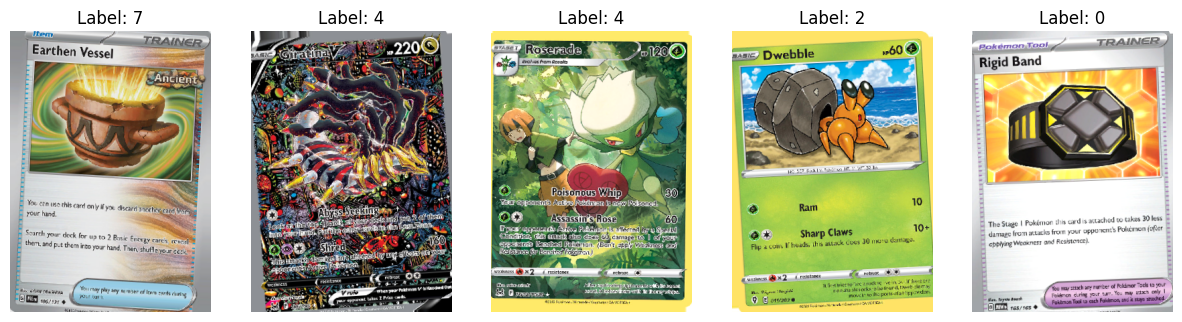

In [5]:
# Mengambil satu batch data latih
x_batch, y_batch = next(train_generator)

# Menampilkan 5 gambar pertama dari batch tersebut
plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(x_batch[i])
    plt.title(f"Label: {y_batch[i].argmax()}")
    plt.axis("off")
plt.show()


In [6]:
print("Membangun Arsitektur Multi-Pooling + Label Smoothing...")

base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# TAHAP 1: FEATURE EXTRACTION (Bekukan base model)
base_model.trainable = False 

x = base_model.output

# 1. Multi-Pooling Strategy
avg_pool = GlobalAveragePooling2D()(x)
max_pool = GlobalMaxPooling2D()(x)
x = Concatenate()([avg_pool, max_pool]) # Menggabungkan rata-rata dan nilai maksimal

# 2. Classifier Layers dengan Batch Normalization
x = BatchNormalization()(x)
x = Dropout(0.5)(x) # Dropout dinaikkan untuk mencegah overfitting
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 3. Penggunaan Label Smoothing (0.1) pada fungsi Loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)


Membangun Arsitektur Multi-Pooling + Label Smoothing...


C:\Users\aryay\AppData\Local\Temp\ipykernel_6580\2312983285.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [7]:
print("\n=== Memulai Tahap 1: Feature Extraction ===")
history_phase1 = model.fit(
    train_generator,
    epochs=10, 
    validation_data=val_generator,
    class_weight=class_weight_dict
)



=== Memulai Tahap 1: Feature Extraction ===
Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 189s 3s/step - accuracy: 0.1645 - loss: 7.8670 - val_accuracy: 0.1647 - val_loss: 8.2170
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.2984 - loss: 6.8471 - val_accuracy: 0.2588 - val_loss: 6.7148
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.3751 - loss: 6.1296 - val_accuracy: 0.2647 - val_loss: 6.0628
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.4075 - loss: 5.5835 - val_accuracy: 0.3118 - val_loss: 5.5495
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.4679 - loss: 5.0502 - val_accuracy: 0.3353 - val_loss: 5.1260
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.4947 - loss: 4.6546 - val_accuracy: 0.3147 - val_loss: 4.9159
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.5065 - loss: 4.2892 - val_accuracy: 0.3353 - val_loss: 4.5882
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.5

In [8]:
# TAHAP 2: FINE-TUNING (Sesuai Acuan: Freeze 70-80% layer awal)
print("\n=== Memulai Tahap 2: Fine-Tuning Terukur ===")
base_model.trainable = True

# MobileNetV2 memiliki 154 layer. Kita bekukan 75% awal (sekitar 115 layer)
freeze_until = int(len(base_model.layers) * 0.75)

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False
for layer in base_model.layers[freeze_until:]:
    layer.trainable = True

# Kompilasi ulang dengan learning rate yang lebih kecil
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

history_phase2 = model.fit(
    train_generator,
    epochs=30, 
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)


=== Memulai Tahap 2: Fine-Tuning Terukur ===
Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - accuracy: 0.3209 - loss: 4.1814 - val_accuracy: 0.3059 - val_loss: 4.2928 - learning_rate: 1.0000e-04
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.4411 - loss: 3.7715 - val_accuracy: 0.3000 - val_loss: 4.2545 - learning_rate: 1.0000e-04
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.5003 - loss: 3.5378 - val_accuracy: 0.3029 - val_loss: 4.1987 - learning_rate: 1.0000e-04
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.5358 - loss: 3.4216 - val_accuracy: 0.2765 - val_loss: 4.3263 - learning_rate: 1.0000e-04
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.5813 - loss: 3.2830 - val_accuracy: 0.2441 - val_loss: 4.7462 - learning_rate: 1.0000e-04
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6276 - loss: 3.1304
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
51/51 ━━━━━━━━━━━━━━

In [9]:
# Menyimpan model yang sudah dilatih ke folder models/
model_path = os.path.join('models', 'mobilenetv2_pokemon_tcg.keras')
model.save(model_path)
print(f"Model berhasil disimpan di: {model_path}")


Model berhasil disimpan di: models\mobilenetv2_pokemon_tcg.keras


In [10]:
# ==========================================
# 4. EVALUASI MODEL PADA DATA UJI (TEST SET)
# ==========================================
TEST_DIR = os.path.join('data', 'processed', 'test')

# Hanya normalisasi, tanpa augmentasi
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # PENTING: Jangan diacak agar y_true dan y_pred sejajar
)

# Menghitung Akurasi dan Loss dasar
print("Mengevaluasi model...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nAkurasi pada Test Set: {test_acc * 100:.2f}%")
print(f"Loss pada Test Set: {test_loss:.4f}")


Found 355 images belonging to 10 classes.
Mengevaluasi model...
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.3155 - loss: 4.1905

Akurasi pada Test Set: 31.55%
Loss pada Test Set: 4.1905


Melakukan prediksi pada Test Set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step

=== Laporan Klasifikasi (Classification Report) ===
                       precision    recall  f1-score   support

                  151       1.00      0.09      0.17        32
      destined-rivals       0.23      0.55      0.33        38
       evolving-skies       0.58      0.19      0.29        36
     journey-together       0.00      0.00      0.00        29
          lost-origin       0.55      0.84      0.67        38
       paldea-evolved       0.31      0.12      0.17        43
        paldean-fates       0.27      0.74      0.39        38
 prismatic-evolutions       0.29      0.29      0.29        28
scarlet-violet-promos       0.22      0.15      0.18        34
       surging-sparks       0.19      0.08      0.11        39

             accuracy                           0.32       355
            macro avg       0.36      0.30      0.26       355
         weighted avg       0.36      0.32      0.2

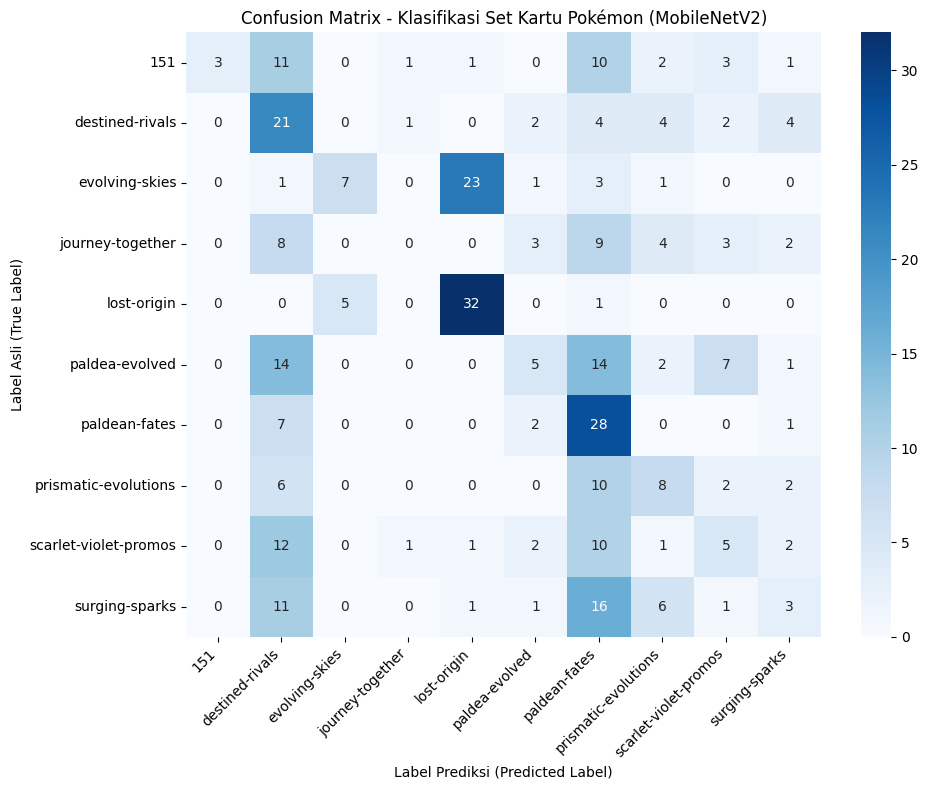

In [11]:
print("Melakukan prediksi pada Test Set...")
# Mendapatkan probabilitas prediksi
predictions = model.predict(test_generator)

# Mengambil indeks kelas dengan probabilitas tertinggi (argmax)
y_pred = np.argmax(predictions, axis=1)

# Mengambil label asli dari generator
y_true = test_generator.classes

# Mengambil nama-nama kelas (10 Set Pokémon)
class_names = list(test_generator.class_indices.keys())

# 1. Classification Report (Precision, Recall, F1-Score)
print("\n=== Laporan Klasifikasi (Classification Report) ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Klasifikasi Set Kartu Pokémon (MobileNetV2)')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Label Prediksi (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Menyimpan gambar Confusion Matrix ke folder reports (opsional tapi disarankan untuk skripsi)
cm_path = os.path.join('reports', 'confusion_matrix_mobilenet.png')
# Pastikan folder reports ada
os.makedirs('reports', exist_ok=True)
plt.savefig(cm_path)
print(f"Confusion Matrix berhasil disimpan di: {cm_path}")

plt.show()


Menghasilkan Learning Curves...
Learning Curves berhasil disimpan di: reports\learning_curves_mobilenet.png


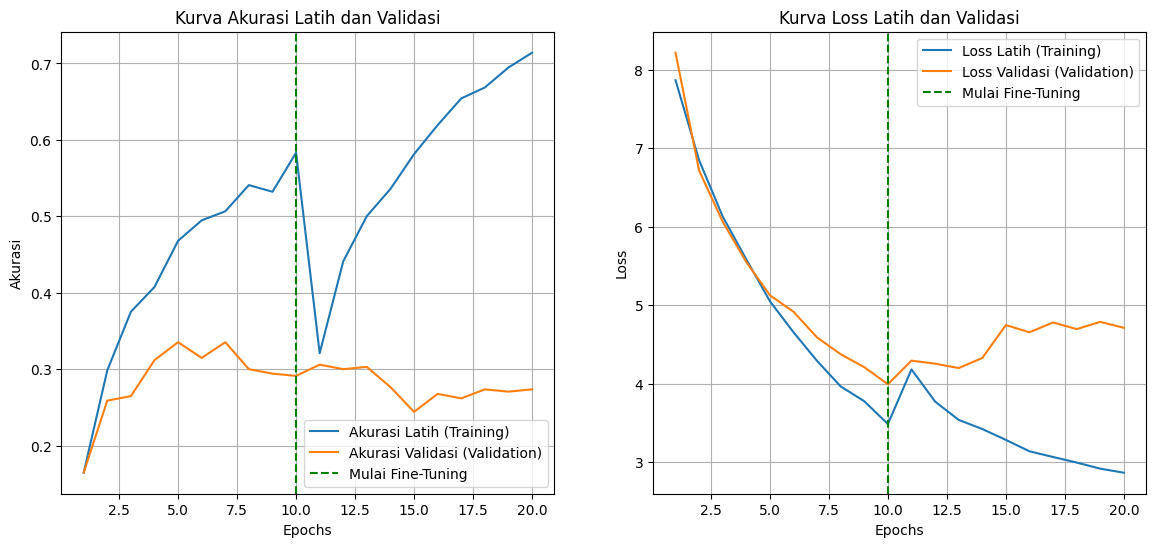

In [12]:
# ==========================================
# 5. VISUALISASI LEARNING CURVES
# ==========================================
print("Menghasilkan Learning Curves...")

# Menggabungkan data metrik dari Tahap 1 (Feature Extraction) dan Tahap 2 (Fine-Tuning)
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

# Menentukan titik transisi fine-tuning
initial_epochs = len(history_phase1.history['accuracy'])
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# 1. Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Latih (Training)')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi (Validation)')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Akurasi Latih dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Latih (Training)')
plt.plot(epochs_range, val_loss, label='Loss Validasi (Validation)')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Loss Latih dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Menyimpan grafik ke folder reports
lc_path = os.path.join('reports', 'learning_curves_mobilenet.png')
plt.savefig(lc_path)
print(f"Learning Curves berhasil disimpan di: {lc_path}")

plt.show()
